ファイルを読み込みます: G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data/shizuoka2023_EyeCenterAngle_saccade_analysis_vel30_excl5s_origin.csv
,区切りファイルとして読み込みます
データ読み込み完了: 732行, 32列
特徴量として使用: 28列
データサイズ: (732, 28)
データの標準化を実行中...
標準化完了
PCAによる次元削減を実行中（次元数: 2）...
PCA完了: 累積寄与率 = 0.4037
K-meansのエルボー法とシルエット分析を実行中...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


クラスター数 2: イナーシャ = 4759.36, シルエットスコア = 0.6861
クラスター数 3: イナーシャ = 3199.68, シルエットスコア = 0.5294
クラスター数 4: イナーシャ = 2475.69, シルエットスコア = 0.4446


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


クラスター数 5: イナーシャ = 1994.47, シルエットスコア = 0.4595
クラスター数 6: イナーシャ = 1659.60, シルエットスコア = 0.3751
クラスター数 7: イナーシャ = 1397.12, シルエットスコア = 0.3765


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


クラスター数 8: イナーシャ = 1234.27, シルエットスコア = 0.3754
シルエットスコアに基づく最適クラスター数: 2
クラスター数を3に設定しました（最適値は2です）
クラスター 0: 563 ポイント
クラスター 1: 148 ポイント
クラスター 2: 21 ポイント


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


PCAの寄与率グラフを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\pca_explained_variance.png
K-meansのエルボー法グラフを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\kmeans_elbow_method.png
IDラベル付きPCAプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\pca_with_ids.png
クラスター情報付きデータを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\pca_clustered_data.csv

すべてのグラフを表示します...


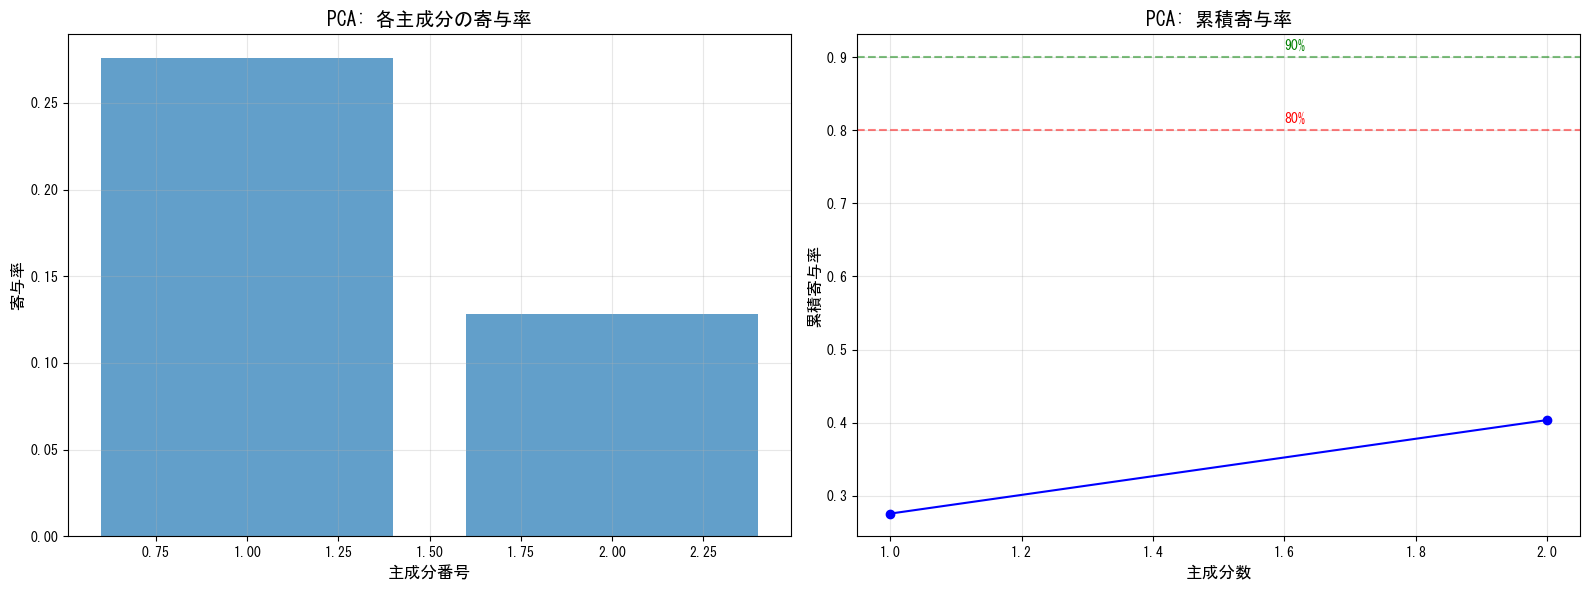

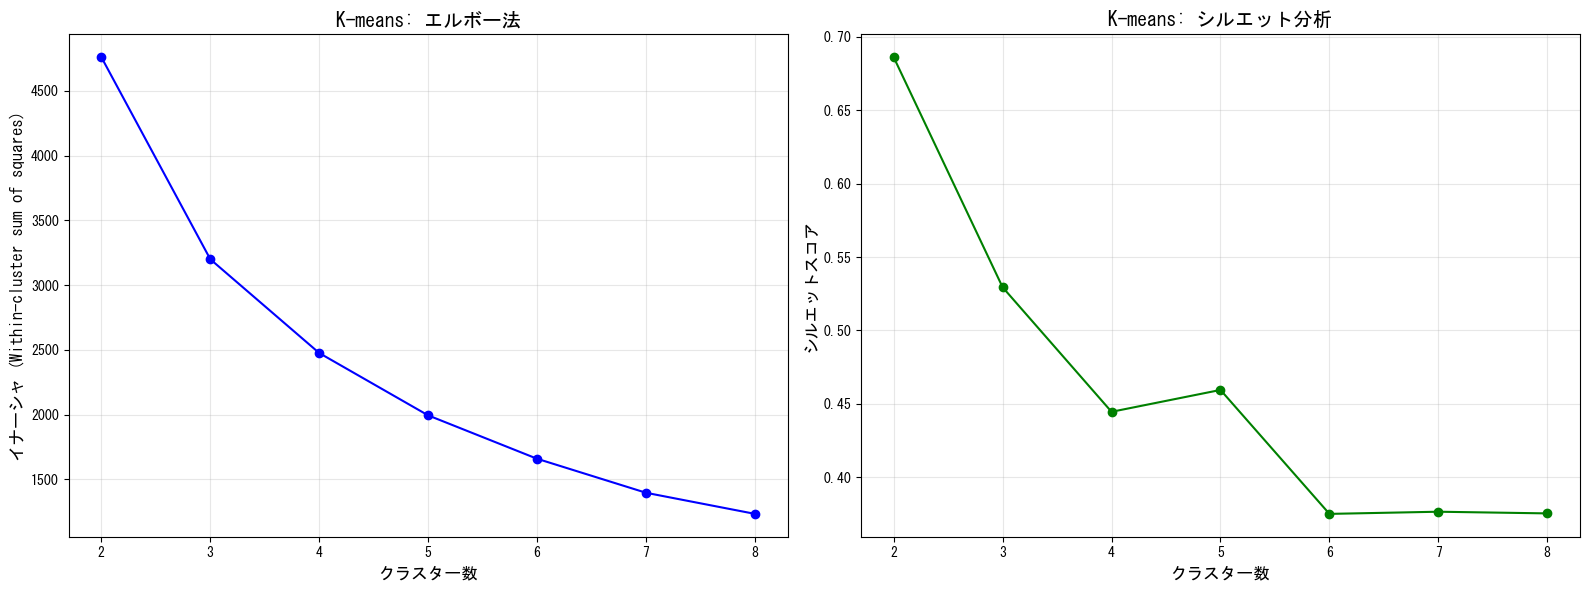

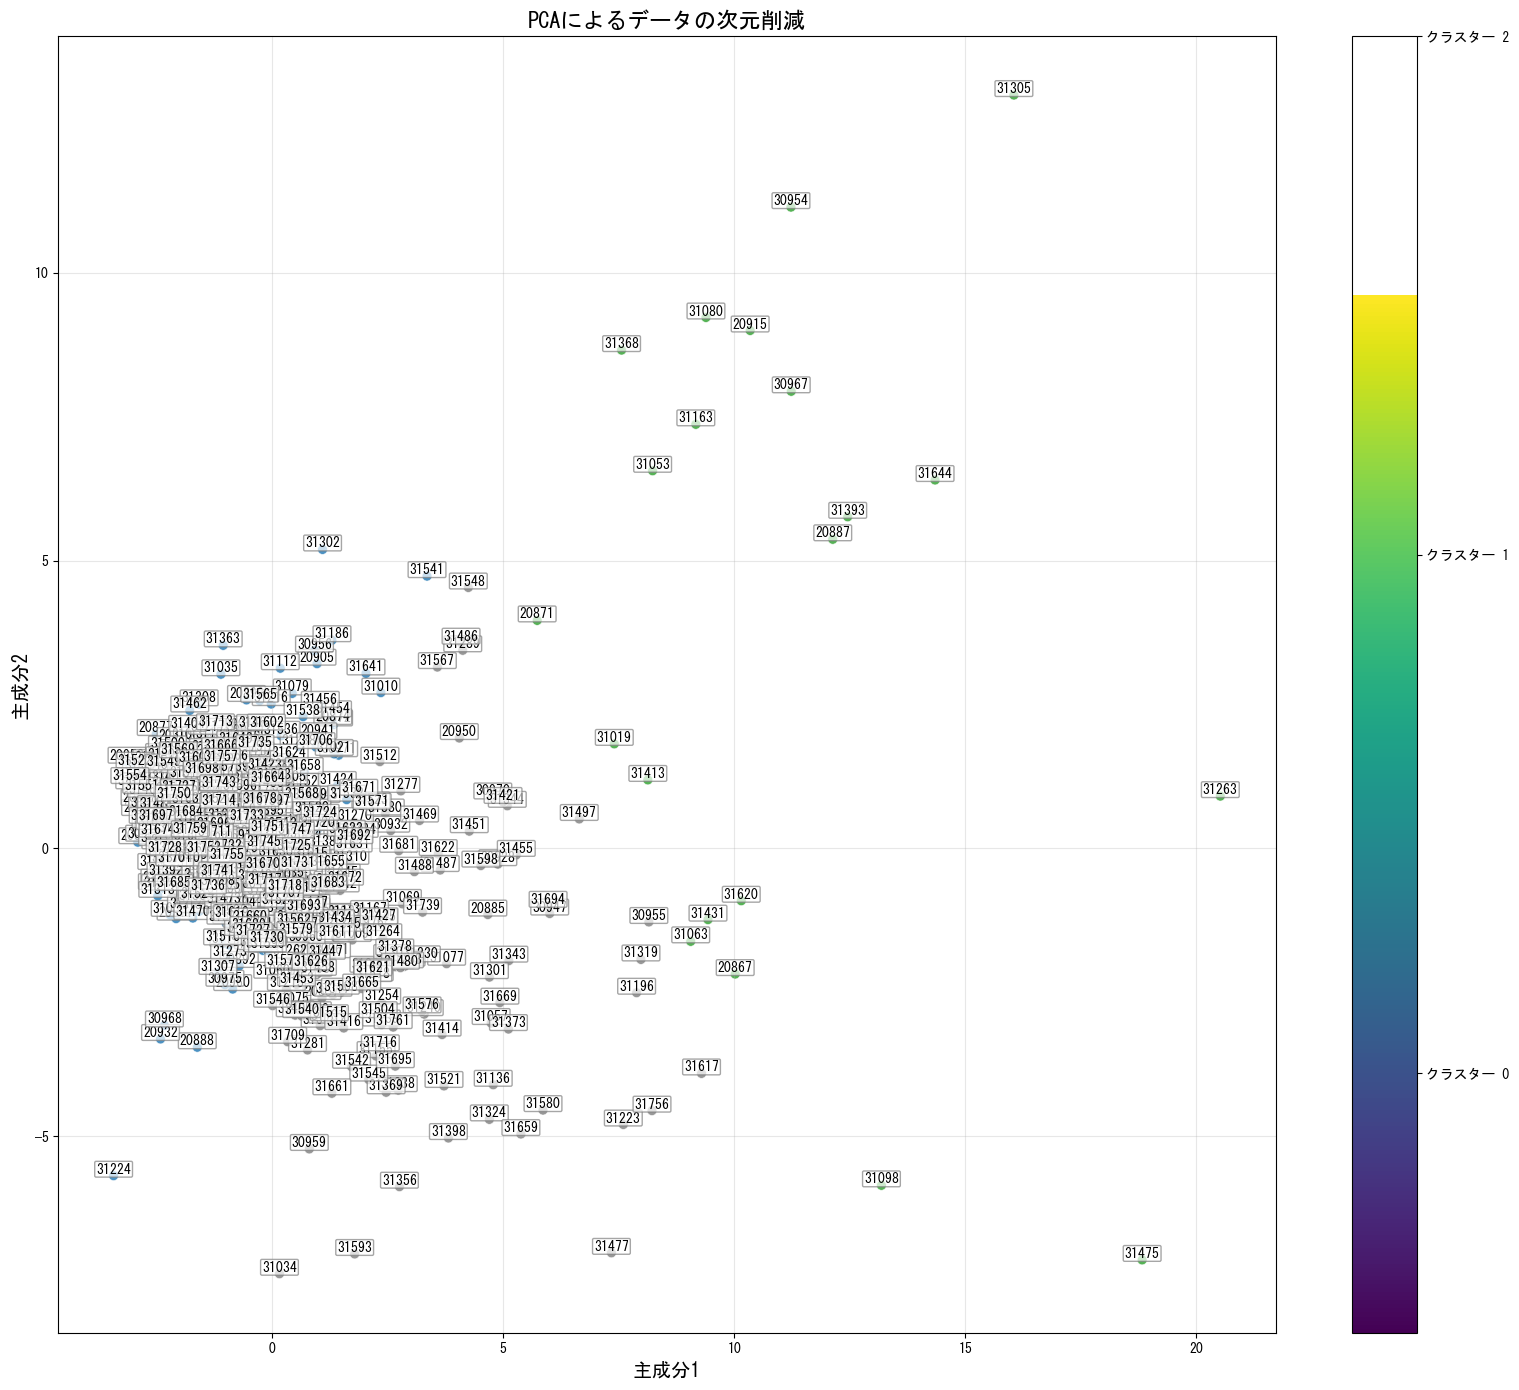

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

# 日本語フォント設定（必要に応じて）
try:
    import matplotlib.font_manager as fm
    font_path = 'C:/Windows/Fonts/msgothic.ttc'  # Windowsの場合のMSゴシック
    if os.path.exists(font_path):
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rcParams['font.family'] = prop.get_name()
except Exception:
    pass  # フォント設定に失敗しても処理を続行

class DimensionalityReducer:
    """データの次元削減を行うクラス (PCAのみ使用)"""
    
    def __init__(self, n_components_pca=2, random_state=42):
        self.n_components_pca = n_components_pca
        self.random_state = random_state
        
        # モデルは後で初期化
        self.scaler = StandardScaler()
        self.pca = None  # データサイズを確認後に初期化
        
        # 変換後のデータ
        self.X_scaled = None
        self.X_pca = None
        
    def fit_transform(self, X):
        """データに対してPCAを適用する"""
        # データの標準化
        print("データの標準化を実行中...")
        self.X_scaled = self.scaler.fit_transform(X)
        print("標準化完了")
        
        # 適切なPCAの次元数を決定
        n_samples, n_features = self.X_scaled.shape
        max_components = min(n_samples, n_features)
        
        if self.n_components_pca is None or self.n_components_pca > max_components:
            # デフォルト値または大きすぎる場合は最大値に設定
            self.n_components_pca = max_components
            print(f"PCAの次元数を{self.n_components_pca}に自動調整しました")
        
        # PCAの初期化と適用
        print(f"PCAによる次元削減を実行中（次元数: {self.n_components_pca}）...")
        self.pca = PCA(n_components=self.n_components_pca, random_state=self.random_state)
        self.X_pca = self.pca.fit_transform(self.X_scaled)
        
        explained_variance_ratio = self.pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance_ratio)
        print(f"PCA完了: 累積寄与率 = {cumulative_variance[-1]:.4f}")
        
        return self.X_pca
    
    def plot_pca_explained_variance(self, max_components=None):
        """PCAの寄与率をプロットする"""
        if self.pca is None:
            raise ValueError("先にfit_transformを実行してください")
        
        # 説明済み分散比の取得
        explained_variance_ratio = self.pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        # 表示する成分数の設定
        if max_components is None:
            max_components = len(explained_variance_ratio)
        else:
            max_components = min(max_components, len(explained_variance_ratio))
        
        # プロットの作成
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # 寄与率のプロット
        ax1.bar(range(1, max_components + 1), explained_variance_ratio[:max_components], alpha=0.7)
        ax1.set_xlabel('主成分番号', fontsize=12)
        ax1.set_ylabel('寄与率', fontsize=12)
        ax1.set_title('PCA: 各主成分の寄与率', fontsize=14)
        ax1.grid(True, alpha=0.3)
        
        # 累積寄与率のプロット
        ax2.plot(range(1, max_components + 1), cumulative_variance[:max_components], 'bo-')
        ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.5)  # 80%の水平線
        ax2.axhline(y=0.9, color='g', linestyle='--', alpha=0.5)  # 90%の水平線
        ax2.text(max_components * 0.8, 0.81, '80%', color='r', fontsize=10)
        ax2.text(max_components * 0.8, 0.91, '90%', color='g', fontsize=10)
        ax2.set_xlabel('主成分数', fontsize=12)
        ax2.set_ylabel('累積寄与率', fontsize=12)
        ax2.set_title('PCA: 累積寄与率', fontsize=14)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

# データの読み込みと前処理
def load_data(file_path):
    """ファイルを読み込み、前処理を行う"""
    print(f"ファイルを読み込みます: {file_path}")
    
    try:
        # 区切り文字を検出
        with open(file_path, 'r') as f:
            first_line = f.readline().strip()
            
        separator = '\t' if '\t' in first_line else (',' if ',' in first_line else '\t')
        print(f"{separator}区切りファイルとして読み込みます")
        
        # CSVファイルの読み込み
        df = pd.read_csv(file_path, sep=separator)
        print(f"データ読み込み完了: {df.shape[0]}行, {df.shape[1]}列")
        
        # 列が1つだけの場合の処理
        if df.shape[1] == 1:
            print("列が1つだけです。カンマ区切りでの再分割を試みます")
            first_col_name = df.columns[0]
            if ',' in str(df[first_col_name].iloc[0]):
                temp_df = df[first_col_name].str.split(',', expand=True)
                headers = temp_df.iloc[0]
                temp_df = temp_df.iloc[1:]
                temp_df.columns = headers
                df = temp_df
                print("カンマ区切りで再分割しました")
        
        # 数値列に変換
        for col in df.columns:
            if col not in ['freq', 'power_spectrum', 'InspectionDateAndId']:
                try:
                    df[col] = pd.to_numeric(df[col])
                except:
                    pass
        
        # 数値列のみを選択
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        print(f"特徴量として使用: {len(numeric_cols)}列")
        
        # 特徴量が空の場合はエラー
        if not numeric_cols:
            raise ValueError("数値特徴量が見つかりません")
        
        # 数値データを抽出
        X = df[numeric_cols].copy()
        X = X.fillna(X.mean())  # 欠損値を平均値で補完
        
        return df, X, numeric_cols
        
    except Exception as e:
        print(f"エラー: {str(e)}")
        raise

def find_optimal_k(embedding, max_clusters=10):
    """エルボー法とシルエットスコアで最適なクラスター数を探索"""
    print("K-meansのエルボー法とシルエット分析を実行中...")
    
    # クラスター数ごとのイナーシャとシルエットスコアを計算
    inertia_values = []
    silhouette_values = []
    k_values = range(2, max_clusters + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embedding)
        inertia_values.append(kmeans.inertia_)
        
        # シルエットスコアの計算（2クラスター以上でのみ計算可能）
        silhouette_avg = silhouette_score(embedding, labels)
        silhouette_values.append(silhouette_avg)
        print(f"クラスター数 {k}: イナーシャ = {kmeans.inertia_:.2f}, シルエットスコア = {silhouette_avg:.4f}")
    
    # 最適なクラスター数の特定（シルエットスコアが最大のもの）
    optimal_k = k_values[np.argmax(silhouette_values)]
    print(f"シルエットスコアに基づく最適クラスター数: {optimal_k}")
    
    # エルボー法とシルエットスコアのプロット
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # エルボー法（イナーシャのプロット）
    ax1.plot(k_values, inertia_values, 'bo-')
    ax1.set_xlabel('クラスター数', fontsize=12)
    ax1.set_ylabel('イナーシャ (Within-cluster sum of squares)', fontsize=12)
    ax1.set_title('K-means: エルボー法', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # シルエットスコアのプロット
    ax2.plot(k_values, silhouette_values, 'go-')
    ax2.set_xlabel('クラスター数', fontsize=12)
    ax2.set_ylabel('シルエットスコア', fontsize=12)
    ax2.set_title('K-means: シルエット分析', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return optimal_k, fig, inertia_values, silhouette_values, k_values

# PCAの図にIDを表示する関数
def plot_clustered_pca_with_ids(df, embedding, clusters, id_column='InspectionDateAndId', 
                       id_type='suffix', fontsize=10, point_size=50, 
                       alpha=0.8, colorbar=True):
    """
    クラスターで色分けしたPCA可視化にIDを表示する関数
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム（IDを含む）
    embedding : numpy.ndarray
        PCAによる2次元埋め込み座標
    clusters : numpy.ndarray
        各ポイントのクラスターID
    id_column : str, optional
        ID列の列名
    id_type : str, optional
        'full'=完全なID, 'suffix'=末尾のみ, 'prefix'=先頭のみ
    fontsize : int, optional
        IDのフォントサイズ
    point_size : int, optional
        ポイントのサイズ
    alpha : float, optional
        ポイントの透明度
    colorbar : bool, optional
        カラーバーを表示するか
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        作成された図のオブジェクト
    ax : matplotlib.axes.Axes
        作成された軸のオブジェクト
    """
    # 図の作成
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # クラスターごとに色を設定
    # カラーマップを3つのクラスターに合わせて設定
    colors = ['#1f77b4', '#7f7f7f', '#2ca02c', '#ff7f0e', '#9467bd']  # 青、グレー、緑、オレンジ、紫
    
    # クラスター数に応じて色を繰り返す
    n_clusters = len(np.unique(clusters))
    colors = colors[:n_clusters]  # 必要な色だけ取得
    
    # クラスターごとにポイントを描画
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=[colors[c] for c in clusters], 
        s=point_size,
        alpha=alpha,
        edgecolor='white',
        linewidth=0.5
    )
    
    # IDを表示
    for i, (x, y) in enumerate(embedding):
        full_id = str(df.iloc[i][id_column])
        
        # IDの処理（表示方法に応じて）
        if id_type == 'suffix' and '_' in full_id:
            # '_'で区切られた末尾の部分を表示
            display_id = full_id.split('_')[-1]
        elif id_type == 'prefix' and '_' in full_id:
            # '_'で区切られた先頭の部分を表示
            display_id = full_id.split('_')[0]
        else:
            # 完全なIDを表示
            display_id = full_id
        
        # テキスト追加（背景を白色に）
        ax.text(
            x, y, 
            display_id,
            fontsize=fontsize,
            ha='center',  # 水平方向の位置揃え
            va='bottom',  # 垂直方向の位置揃え
            bbox=dict(
                boxstyle="round,pad=0.1",
                fc="white",
                ec="gray",
                alpha=0.7
            )
        )
    
    # カラーバーを追加（オプション）
    if colorbar:
        cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(0, n_clusters-1)), ax=ax)
        cbar.set_ticks(np.arange(n_clusters) + 0.5)
        cbar.set_ticklabels([f'クラスター {i}' for i in range(n_clusters)])
    
    # 軸ラベルとタイトル
    ax.set_xlabel('主成分1', fontsize=14)
    ax.set_ylabel('主成分2', fontsize=14)
    ax.set_title('PCAによるデータの次元削減', fontsize=16)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# メイン処理
if __name__ == "__main__":
    # ファイルパスの設定
    path = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data"
    file_path = f"{path}/features_test_nolabel.csv"
    
    # データの読み込みと前処理
    df, X, numeric_cols = load_data(file_path)
    
    # データのサイズを確認
    print(f"データサイズ: {X.shape}")
    
    # 次元削減の実行（PCAのみ使用）
    reducer = DimensionalityReducer(n_components_pca=2)
    embedding = reducer.fit_transform(X)
    
    # PCAの寄与率をプロット
    pca_fig = reducer.plot_pca_explained_variance(max_components=20)  # 最初の20成分のみ表示
    
    # K-meansのエルボー法とシルエット分析
    optimal_k, kmeans_fig, _, _, _ = find_optimal_k(embedding, max_clusters=8)
    
    # ユーザーが指定したクラスター数または最適なクラスター数を使用
    n_clusters = 3  
    print(f"クラスター数を{n_clusters}に設定しました（最適値は{optimal_k}です）")
    
    # クラスタリングの実行
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embedding)
    
    # クラスター情報をデータフレームに追加
    df['cluster'] = clusters
    df['pca_x'] = embedding[:, 0]
    df['pca_y'] = embedding[:, 1]
    
    # クラスターごとのポイント数をカウント
    cluster_counts = np.bincount(clusters)
    for i, count in enumerate(cluster_counts):
        print(f"クラスター {i}: {count} ポイント")
    
    # 結果を保存するディレクトリ
    result_path = r"G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result"
    os.makedirs(result_path, exist_ok=True)
    
    # PCAの寄与率グラフを保存
    pca_plot_path = os.path.join(result_path, "pca_explained_variance.png")
    pca_fig.savefig(pca_plot_path, dpi=300, bbox_inches='tight')
    print(f"PCAの寄与率グラフを保存しました: {pca_plot_path}")
    
    # K-meansのエルボー法グラフを保存
    kmeans_plot_path = os.path.join(result_path, "kmeans_elbow_method.png")
    kmeans_fig.savefig(kmeans_plot_path, dpi=300, bbox_inches='tight')
    print(f"K-meansのエルボー法グラフを保存しました: {kmeans_plot_path}")
    
    # PCAプロットを作成（IDラベル付き）
    fig, ax = plot_clustered_pca_with_ids(
        df,
        embedding,
        clusters,
        id_type='suffix',     # 'suffix', 'prefix', 'full' から選択
        fontsize=10,          # IDのフォントサイズ
        point_size=50,        # ポイントのサイズ
        alpha=0.8,            # ポイントの透明度
        colorbar=True         # カラーバーを表示するか
    )
    
    # IDラベル付きプロットを保存
    plot_path = os.path.join(result_path, "pca_with_ids.png")
    fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"IDラベル付きPCAプロットを保存しました: {plot_path}")
    
    # データを保存
    csv_path = os.path.join(result_path, "pca_clustered_data.csv")
    df.to_csv(csv_path, index=False)
    print(f"クラスター情報付きデータを保存しました: {csv_path}")
    
    # プロットを表示
    print("\nすべてのグラフを表示します...")
    plt.show()